# 05 · Seeing where the model looks

A classifier that is right can still be right for the wrong reason. The three devices in this
project look different from one another, so a model could learn to recognise the scanner instead of
the disease, and that shortcut would score well here and fail on the next machine. This notebook
puts a heat map over each scan showing which part of the image the decision rested on, so that the
question can be looked at rather than assumed.

It then turns to the errors. The delivered model is correct on 27 of the 37 clinic scans, and the
10 it misses are worth more attention than the 27 it gets right, because they are where the limits
of the method show.

## Setup

The cell below loads the delivered checkpoint and the per-scan clinic results that notebook 04
reported. The heat maps themselves are computed further down, one scan at a time.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import torch

from ocular import config
from ocular.classifier import data, explain
from ocular.classifier import model as omodel
from ocular.classifier.data import PreConfig
from ocular.classifier.preprocess import load_gray
from ocular.classifier.train import get_device

device = get_device()
cfg = PreConfig(384, 256, crop=True, curvature=True)

# The delivered checkpoint. See the top-level README for how to obtain it.
net = omodel.build_model("convnext_tiny", pretrained=False)
net.load_state_dict(torch.load(config.require_ckpt(), map_location=device))
net = net.to(device).eval()

clinic = pd.read_csv(config.ROOT / "experiments" / "results" / "clinic_scan_e1.csv")
frame = data._clinic_frame()

## How the heat map is made

The method is Grad-CAM, and the idea behind it is simple.

A convolutional network ends with a stack of feature maps, each one a small grid that lights up
where some pattern was found. The network makes its decision by combining them. Grad-CAM asks how
much each of those maps pushed the score of the predicted class upward, uses that as a weight, adds
the maps together in those proportions, and keeps only the positive part. What is left is a small
grid that is bright where the evidence for the answer was, and it is stretched back over the scan.

Two limits are worth stating before looking at any picture. The grid here is 8 by 12, which is 96
values covering a scan of 256 by 384, so each cell stands for a square of about 32 pixels. The map
looks smooth and precise once it is enlarged, and it is neither. It also shows where the decision
came from and not why, so a bright region is not an outline of a lesion and should not be read as
one.

## One scan from each class

The four panels below show one clinic scan of each class with its heat map beneath it. What to look
for is whether the bright area sits on the retinal band, which is the tissue, or drifts into the
dark background and the frame edges, which would belong to the device rather than to the eye.

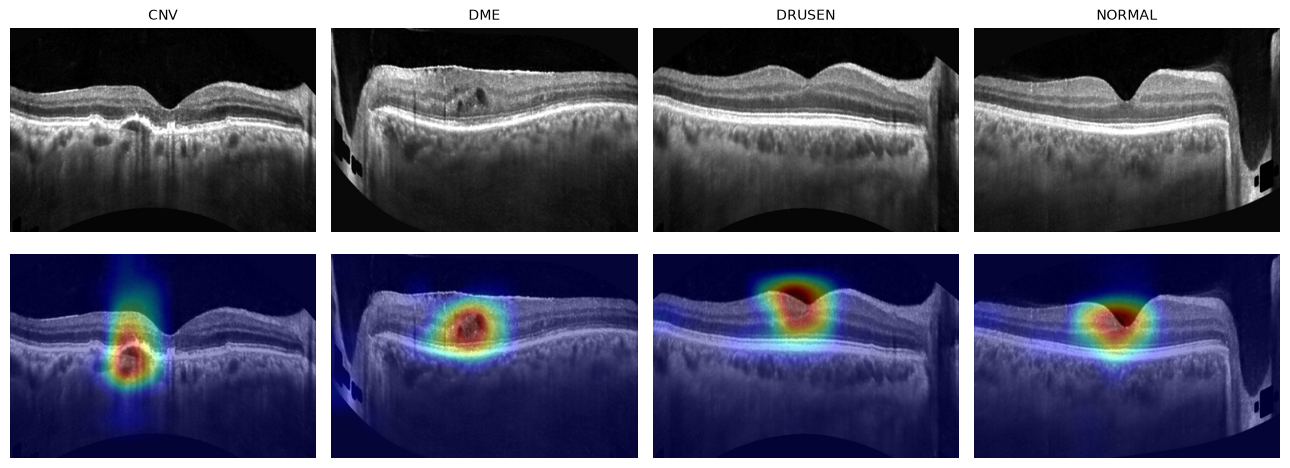

In [2]:
examples = {c: frame[frame["cls"] == c]["path"].iloc[0] for c in config.CLASSES}

fig, axes = plt.subplots(2, len(examples), figsize=(13, 5))
for j, (cls, path) in enumerate(examples.items()):
    scan, cam = explain.explain_scan(net, path, cfg, device=device)
    axes[0, j].imshow(scan, cmap="gray")
    axes[0, j].set_title(cls, fontsize=10)
    axes[1, j].imshow(explain.overlay(scan, cam))
    for ax in (axes[0, j], axes[1, j]):
        ax.axis("off")
plt.tight_layout()
plt.show()

## Every error is a drusen scan

Before looking at the maps of the errors, it helps to see how the errors are distributed. The table
below lists every scan the model got wrong, with the probability it gave to each of the four
classes, ordered by how much belief it placed in the correct answer.

All ten are drusen. No CNV, DME or normal scan is missed, which says that the difficulty is not
spread across the problem but sits in one class, the one defined by the smallest features.

In [3]:
miss = (clinic[clinic["truth"] != clinic["pred"]]
        .sort_values("p_DRUSEN")
        .reset_index(drop=True))

view = miss[["name", "truth", "pred", "p_CNV", "p_DME", "p_DRUSEN", "p_NORMAL"]].copy()
view["name"] = view["name"].str.replace(".png", "", regex=False)
view.round(3)

,name,truth,pred,p_CNV,p_DME,p_DRUSEN,p_NORMAL
0,DRUSEN_10__p0,DRUSEN,NORMAL,0.000,0.001,0.007,0.992
1,DRUSEN_4__R,DRUSEN,NORMAL,0.002,0.010,0.011,0.977
2,DRUSEN_3__L,DRUSEN,NORMAL,0.000,0.004,0.017,0.978
3,DRUSEN_9__L,DRUSEN,DME,0.004,0.683,0.024,0.289
4,DRUSEN_13__R,DRUSEN,DME,0.282,0.628,0.040,0.050
5,DRUSEN_11__p0,DRUSEN,NORMAL,0.003,0.065,0.056,0.876
6,DRUSEN_8__p0,DRUSEN,NORMAL,0.003,0.019,0.087,0.891
7,DRUSEN_6__p0,DRUSEN,NORMAL,0.013,0.095,0.105,0.787
8,DRUSEN_2__L,DRUSEN,NORMAL,0.001,0.020,0.175,0.803
9,DRUSEN_4__L,DRUSEN,CNV,0.722,0.010,0.265,0.003


## Two kinds of miss

The table separates the errors into two groups, and the maps below show that they fail in
different ways.

**Seven are read as a healthy retina**, with the model placing between 79 and 99 percent on NORMAL
and almost nothing on drusen. Their maps sit squarely on the retinal band, usually near the foveal
dip, so the model looked in the right place and read the tissue as normal. These are not close
calls. It is not hesitating between two answers, it is confident that there is nothing there. What
that points at is the scanner rather than the class, because on the device the model trained on it
recovers 0.996 of drusen, more than any other class. The tissue is visible and the model is looking
at it, but this scanner renders it in a form the model does not recognise.

**Three are read as a different disease**, DRUSEN_9__L and DRUSEN_13__R as DME and DRUSEN_4__L as
CNV. The confidence is lower, between 63 and 72 percent, and more belief is left on drusen. Their
maps also behave differently. On two of the three a bright region sits away from the retina
altogether, out in the dark background where there is no tissue to read, which is not something the
correctly classified scans do.

Two explanations for that off-tissue attention were tested and neither held. The small device
markings that the OPTOPOL export leaves in the dark corners were blanked out and the scans rescored,
which changed no prediction and left the bright region where it was. The curved dark area that the
curvature correction opens up when it shifts columns was ruled out by rescoring the clinic set with
that step switched off, which left both accuracy and drusen recall untouched. Whatever
draws attention there is therefore not what decides the answer, and the question of what it is
remains open.

Four of the ten are drawn below, two from each group, with the class the model chose above
each one. Each column shows the scan as it came out of the report, then the same scan after
preprocessing, then the heat map over it. The first two rows are worth comparing, because the
crop to the retinal band and the flattening change what is left for the model to read. The full
list stays in the table above.

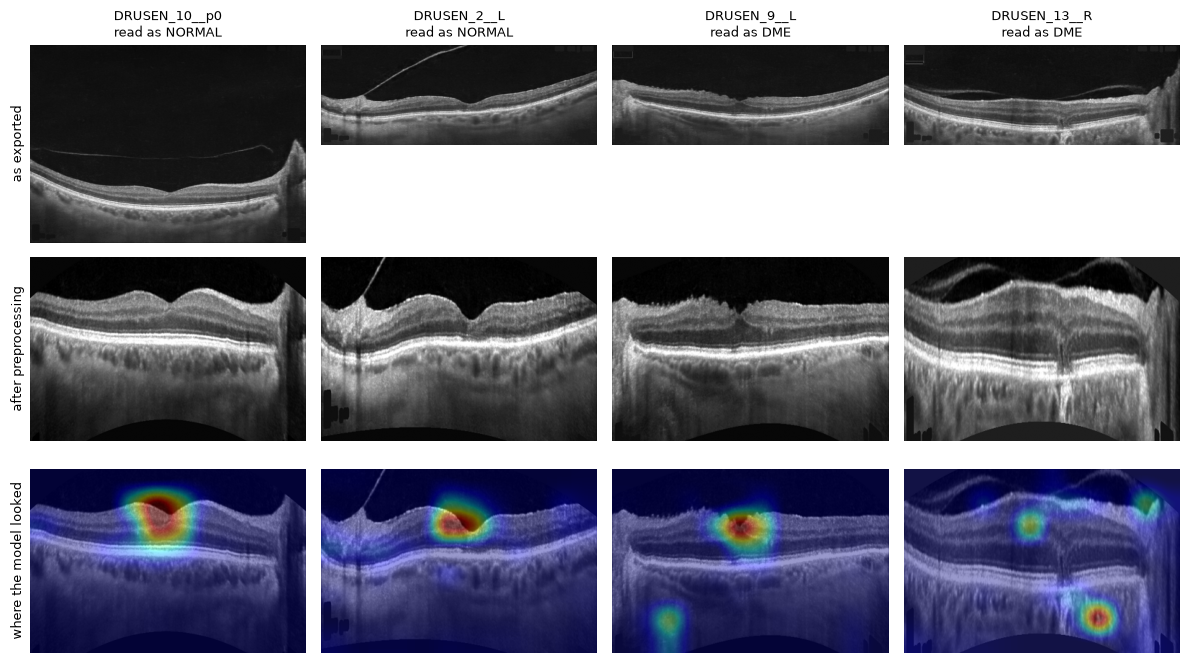

In [4]:
# two misses read as healthy, two read as another disease
shown = ["DRUSEN_10__p0.png", "DRUSEN_2__L.png", "DRUSEN_9__L.png", "DRUSEN_13__R.png"]
rows = ["as exported", "after preprocessing", "where the model looked"]

fig, axes = plt.subplots(3, len(shown), figsize=(3 * len(shown), 7))
for j, fname in enumerate(shown):
    row = miss[miss["name"] == fname].iloc[0]
    path = data.CLINIC_DIR / fname
    scan, cam = explain.explain_scan(net, path, cfg, device=device)
    for r, img in enumerate([load_gray(path), scan, explain.overlay(scan, cam)]):
        ax = axes[r, j]
        ax.imshow(img, cmap="gray" if img.ndim == 2 else None)
        ax.set_xticks([])
        ax.set_yticks([])
        for side in ax.spines.values():
            side.set_visible(False)
        # anchor to the top so the exported scans, which differ in shape, still line up
        ax.set_anchor("N")
    axes[0, j].set_title(f"{fname.replace('.png', '')}\nread as {row['pred']}", fontsize=9)
for r, name in enumerate(rows):
    axes[r, 0].set_ylabel(name, fontsize=9)
plt.tight_layout()
plt.show()

## How the map is computed

The code is in `ocular/classifier/explain.py` and is reached through `explain_scan`, which takes a
file and a preprocessing configuration and returns the prepared scan together with its map.

**Choosing the layer.** `target_layer` picks the last part of the network that still has a spatial
shape, since a map can only be drawn from something that still knows where things are. It is
`features[-1]` for ConvNeXt and the custom network and `layer4[-1]` for ResNet. A Vision Transformer
has no such layer and is refused with a clear message rather than being read incorrectly.

**Building the map.** `gradcam` attaches one hook that catches the activations on the way forward
and another that catches the gradients on the way back, runs a single backward pass from the
predicted class, averages each gradient map into one weight, adds the activations in those
proportions, and keeps the positive part. The result is rescaled to run from zero to one and
enlarged to the size of the scan.

**Drawing it.** `overlay` puts a colour map over the grey scan and blends the two, clipping the
result so it stays inside the range an image viewer expects. The same function draws the heat map
in the application, so what a clinician sees there is what is shown here.

## Summary

- Grad-CAM shows **which part of a scan a decision rested on**, by weighting the last feature maps
  of the network by how much each pushed the predicted class upward.
- Read it with care. The map holds **96 values** stretched over the whole scan, and it shows where
  the evidence was rather than what the model understood, so it is not a lesion outline.
- On the correctly classified scans the bright region sits **on the retinal band**, which is what a
  model reading tissue rather than the device should do.
- **All ten errors are drusen scans**, so the weakness is confined to one class rather than spread
  across the problem.
- Those errors split in two. **Seven are read as healthy** with high confidence, and **three are
  read as another disease** with visibly lower confidence and with attention that wanders off the
  tissue.
- The cause is **the change of scanner, not the class**. The same model recovers 0.996 of drusen on
  the device it trained on, so the pathology is not too small to see. Two mechanical explanations
  for the off-tissue attention, the device markings and the curvature cutout, were both tested and
  rejected.

The following notebook, `06`, leaves the classifier and begins the retrieval assistant.